# Koopman-Operator-Based MPC for Payload-Carrying / Wind-Disturbed Drones

This notebook consolidates the full 6-step project pipeline into one place:

1. Fly and log data
2. Train Koopman model (EDMD)
3. MPC controller
4. Environment selector
5. Disturbance scenario testing
6. PID / LQR baseline comparison and metrics

**Requirements:** `gym-pybullet-drones`, `numpy`, `scipy`, `cvxpy`, `osqp`, `matplotlib`.
Run cells in order — later steps depend on files saved by earlier ones.


In [1]:
import numpy as np
import os
os.makedirs("data/nominal", exist_ok=True)
os.makedirs("data/windy", exist_ok=True)
os.makedirs("data/payload", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("results/plots", exist_ok=True)
os.chdir(r"D:\Projects\koopman-mpc-drone")
print("Working directory set to:", os.getcwd())


Working directory set to: D:\Projects\koopman-mpc-drone


## Step 1 — Fly and Log Data

Uses `gym-pybullet-drones` with a PID-stabilized controller flying to randomized
height targets, so the drone stays upright while covering a wide height range
(this was found to matter a lot — random per-motor noise alone caused tumbling).
Three conditions are collected: **nominal**, **windy** (constant horizontal force),
and **payload** (extra mass added mid-flight).


In [2]:
import numpy as np
import os
from gym_pybullet_drones.envs.CtrlAviary import CtrlAviary
from gym_pybullet_drones.control.DSLPIDControl import DSLPIDControl
from gym_pybullet_drones.utils.enums import DroneModel, Physics
import pybullet as p

def collect_data(condition="nominal", duration_sec=60, ctrl_freq=48):
    num_steps = duration_sec * ctrl_freq
    save_dir = f"data/{condition}"
    os.makedirs(save_dir, exist_ok=True)

    env = CtrlAviary(
        drone_model=DroneModel.CF2X, num_drones=1,
        physics=Physics.PYB, pyb_freq=240, ctrl_freq=ctrl_freq, gui=False
    )
    obs, info = env.reset()
    ctrl = DSLPIDControl(drone_model=DroneModel.CF2X)

    extra_payload_mass = 0.01 if condition == "payload" else 0.0
    wind_force = np.array([0.05, 0.0, 0.0]) if condition == "windy" else np.array([0.0, 0.0, 0.0])

    drone_id = env.DRONE_IDS[0]
    payload_applied = False

    log_states, log_actions = [], []
    target_hold_steps = 96  # ~2s per random waypoint
    current_target = np.array([0.0, 0.0, 0.3])

    for step in range(num_steps):
        if step % target_hold_steps == 0:
            current_target = np.array([
                np.random.uniform(-0.3, 0.3),
                np.random.uniform(-0.3, 0.3),
                np.random.uniform(0.1, 1.2)
            ])

        state = obs[0]
        rpm, _, _ = ctrl.computeControlFromState(
            control_timestep=1 / ctrl_freq, state=state,
            target_pos=current_target, target_rpy=np.array([0, 0, 0])
        )
        action = rpm.reshape(1, 4)

        obs, reward, terminated, truncated, info = env.step(action)

        if condition == "windy":
            p.applyExternalForce(drone_id, -1, forceObj=wind_force.tolist(),
                                  posObj=[0, 0, 0], flags=p.LINK_FRAME,
                                  physicsClientId=env.CLIENT)

        if condition == "payload" and step == num_steps // 2 and not payload_applied:
            current_mass = p.getDynamicsInfo(drone_id, -1, physicsClientId=env.CLIENT)[0]
            p.changeDynamics(drone_id, -1, mass=current_mass + extra_payload_mass,
                              physicsClientId=env.CLIENT)
            payload_applied = True

        log_states.append(obs[0].copy())
        log_actions.append(action[0].copy())

        if terminated or truncated:
            obs, info = env.reset()
            payload_applied = False

    env.close()
    log_states, log_actions = np.array(log_states), np.array(log_actions)
    np.savez(f"{save_dir}/flight_log.npz", states=log_states, actions=log_actions)

    z = log_states[:, 2]
    roll = log_states[:, 7]
    print(f"[{condition}] Saved {log_states.shape[0]} steps | "
          f"Z: {z.min():.3f}-{z.max():.3f} | roll std: {roll.std():.3f}")
    return log_states, log_actions


D:\Projects\gym-pybullet-drones\gym_pybullet_drones\envs\BaseAviary.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
# Run this for each condition (can be slow — ~60s of sim time each)
for cond in ["nominal", "windy", "payload"]:
    collect_data(condition=cond, duration_sec=60)


[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


d:\Projects\koopman-mpc-drone\venv\Lib\site-packages\gymnasium\spaces\box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
d:\Projects\koopman-mpc-drone\venv\Lib\site-packages\gymnasium\spaces\box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


[nominal] Saved 2880 steps | Z: 0.116-1.159 | roll std: 0.092
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
[windy] Saved 2880 steps | Z: 0.116-1.182 | roll std: 0.079
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
[payload] Saved 2880 steps | Z: 0.010-1.

## Step 2 — Train Koopman Model (EDMD)

Fits a linear model in a *lifted* space using Extended Dynamic Mode Decomposition.
The lifting function includes the raw state, elementwise squares, and cross-terms
between orientation and angular-velocity dimensions (needed to capture rotational
coupling — plain elementwise squares alone fit poorly here).

Only the first 16 physical states (position, quaternion, RPY, velocity, angular
velocity) are modeled — the last 4 raw-RPM columns are dropped since they're
just near-copies of the previous control input, not meaningful state.


In [4]:
import numpy as np
from itertools import combinations

def train_koopman(condition="nominal"):
    data = np.load(f"data/{condition}/flight_log.npz")
    states_full = data["states"]
    actions = data["actions"]
    states = states_full[:, :16]  # drop raw RPM columns

    X, Xp, U = states[:-1], states[1:], actions[:-1]

    x_mean, x_std = X.mean(axis=0), X.std(axis=0) + 1e-8
    u_mean, u_std = U.mean(axis=0), U.std(axis=0) + 1e-8

    Xn, Xpn, Un = (X - x_mean) / x_std, (Xp - x_mean) / x_std, (U - u_mean) / u_std

    cross_idx = list(range(3, 16))  # quaternion, RPY, angular velocity
    cross_pairs = list(combinations(cross_idx, 2))

    def lift(x):
        quad = x ** 2
        cross = np.stack([x[:, i] * x[:, j] for i, j in cross_pairs], axis=1)
        return np.concatenate([x, quad, cross], axis=1)

    Psi_X, Psi_Xp = lift(Xn), lift(Xpn)

    Z = np.hstack([Psi_X, Un])
    reg = 1e-4
    ZtZ = Z.T @ Z + reg * np.eye(Z.shape[1])
    ZtY = Z.T @ Psi_Xp
    AB_T = np.linalg.solve(ZtZ, ZtY)

    L = Psi_X.shape[1]
    A, B = AB_T[:L, :].T, AB_T[L:, :].T

    Psi_pred = Psi_X @ A.T + Un @ B.T
    rmse = np.sqrt(np.mean((Psi_pred[:, :16] - Psi_Xp[:, :16]) ** 2))
    print(f"[{condition}] Lifted dim={Psi_X.shape[1]} | 16-state RMSE (normalized) = {rmse:.4f}")

    np.savez(f"data/{condition}/koopman_model.npz",
             A=A, B=B, x_mean=x_mean, x_std=x_std, u_mean=u_mean, u_std=u_std,
             cross_pairs=np.array(cross_pairs))
    return A, B


In [5]:
for cond in ["nominal", "windy", "payload"]:
    train_koopman(cond)


[nominal] Lifted dim=110 | 16-state RMSE (normalized) = 0.2394
[windy] Lifted dim=110 | 16-state RMSE (normalized) = 0.2441
[payload] Lifted dim=110 | 16-state RMSE (normalized) = 0.1500


## Step 3 — MPC Controller

QP-based linear MPC over the lifted Koopman dynamics, solved with `cvxpy`/OSQP.

Key implementation notes learned during development:
- **State variables should be eliminated, not carried as free variables with
  equality constraints** — the naive formulation (carrying the full lifted
  trajectory as a `cp.Variable` tied together with `Psi[t+1] == A@Psi[t] + B@U[t]`
  constraints) was numerically fragile and caused the solver to fail on nearly
  every call. Substituting the dynamics directly (as done below) fixed this.
- Orientation dimensions (quaternion, roll, pitch) need a **separate, higher
  weight** than the rest of the state, or the controller will let the drone tip
  over while chasing height tracking.
- **Known limitation (documented finding, not fixed):** even with orientation
  weighting, instability was found to persist over long enough runs, including
  during plain hovering with *zero* commanded climb. This points to a deeper
  limitation of Euler-angle/quaternion-based Koopman lifting functions
  (consistent with singularity issues described in Narayanan et al., "SE(3)
  Koopman-MPC", IFAC-PapersOnLine 2023) rather than something weight-tuning
  alone can resolve. The base paper being replicated uses this same
  representation, so this is reported as an honest limitation rather than
  worked around.


In [6]:
import cvxpy as cp
from itertools import combinations

class MPCController:
    def __init__(self, target_z=0.3, horizon=6):
        self.N_STATE = 16
        self.N_ACTION = 4
        self.HORIZON = horizon
        self._models = {}
        self._last_u_norm = np.zeros(self.N_ACTION)

        self.target_state_raw = np.zeros(self.N_STATE)
        self.target_state_raw[2] = target_z
        self.target_state_raw[6] = 1.0  # identity quaternion (level)

        self.STATE_WEIGHT = np.ones(self.N_STATE)
        self.STATE_WEIGHT[3:7] = 40.0   # quaternion
        self.STATE_WEIGHT[7] = 40.0     # roll
        self.STATE_WEIGHT[8] = 40.0     # pitch
        self.STATE_WEIGHT[2] = 15.0     # height

    def _load_model(self, condition):
        if condition not in self._models:
            m = np.load(f"data/{condition}/koopman_model.npz")
            self._models[condition] = {
                "A": m["A"], "B": m["B"],
                "x_mean": m["x_mean"], "x_std": m["x_std"],
                "u_mean": m["u_mean"], "u_std": m["u_std"],
                "cross_pairs": [tuple(p) for p in m["cross_pairs"]]
            }
        return self._models[condition]

    def _lift(self, x, cross_pairs):
        quad = x ** 2
        cross = np.array([x[i] * x[j] for i, j in cross_pairs])
        return np.concatenate([x, quad, cross])

    def solve(self, current_state_raw, condition="nominal"):
        if np.any(np.isnan(current_state_raw)) or np.any(np.isinf(current_state_raw)) \
                or np.any(np.abs(current_state_raw) > 1e4):
            model = self._load_model(condition)
            u0_raw = self._last_u_norm * model["u_std"] + model["u_mean"]
            return np.clip(u0_raw, 0, 25000)

        model = self._load_model(condition)
        A, B = model["A"], model["B"]
        x_mean, x_std = model["x_mean"], model["x_std"]
        u_mean, u_std = model["u_mean"], model["u_std"]
        cross_pairs = model["cross_pairs"]

        x0_norm = (current_state_raw - x_mean) / x_std
        target_norm = (self.target_state_raw - x_mean) / x_std
        psi0 = self._lift(x0_norm, cross_pairs)
        target_lifted = self._lift(target_norm, cross_pairs)

        U = cp.Variable((self.HORIZON, self.N_ACTION))
        Q_weight, R_weight, DU_weight = 20.0, 0.1, 1.0
        U_BOUND, MAX_RATE = 4.0, 1.0

        cost, constraints = 0, []
        prev_u = self._last_u_norm
        psi_t = psi0
        for t in range(self.HORIZON):
            psi_next = A @ psi_t + B @ U[t]
            state_error = psi_next[:self.N_STATE] - target_lifted[:self.N_STATE]
            weighted_error = cp.multiply(state_error, self.STATE_WEIGHT)
            cost += Q_weight * cp.sum_squares(weighted_error)
            cost += R_weight * cp.sum_squares(U[t])
            cost += DU_weight * cp.sum_squares(U[t] - prev_u)
            constraints += [U[t] <= U_BOUND, U[t] >= -U_BOUND]
            constraints += [U[t] - prev_u <= MAX_RATE, U[t] - prev_u >= -MAX_RATE]
            prev_u = U[t]
            psi_t = psi_next

        problem = cp.Problem(cp.Minimize(cost), constraints)
        try:
            problem.solve(solver=cp.OSQP, verbose=False, eps_abs=1e-5, eps_rel=1e-5, max_iter=20000)
        except cp.error.SolverError:
            pass

        if U.value is None or np.any(np.isnan(U.value)):
            u0_raw = self._last_u_norm * u_std + u_mean
            return np.clip(u0_raw, 0, 25000)

        u0_norm = U.value[0]
        self._last_u_norm = u0_norm
        u0_raw = u0_norm * u_std + u_mean
        return np.clip(u0_raw, 0, 25000)

mpc = MPCController(target_z=0.3)
print("MPC controller initialized.")


MPC controller initialized.


## Step 4 — Environment Selector

Nearest-mean classifier, matching the base paper's Algorithm 1 approach: precision
values (mean RPY + angular-velocity signature) are computed per condition from
training flight data, and a live window of recent states is compared to all three
signatures every 5 seconds (240 steps @ 48Hz) to pick the currently-active
Koopman model.


In [7]:
class EnvironmentSelector:
    def __init__(self, conditions=("nominal", "windy", "payload")):
        self.conditions = conditions
        self.sig_idx = list(range(7, 10)) + list(range(13, 16))  # RPY + angular velocity
        self.precision = {}
        for cond in conditions:
            data = np.load(f"data/{cond}/flight_log.npz")
            states = data["states"][:, :16]
            self.precision[cond] = states[:, self.sig_idx].mean(axis=0)
        np.savez("data/environment_selector_precision.npz", **self.precision)

    def select(self, window_states_16):
        sig = window_states_16[:, self.sig_idx].mean(axis=0)
        dists = {c: np.linalg.norm(sig - self.precision[c]) for c in self.conditions}
        return min(dists, key=dists.get), dists

selector = EnvironmentSelector()
print("Environment selector precision values:")
for c, v in selector.precision.items():
    print(f"  {c}: {v}")


Environment selector precision values:
  nominal: [-0.00021614  0.00035986  0.00321513 -0.00042803  0.00010676 -0.00876553]
  windy: [-3.57556733e-04 -3.80477297e-02  3.23067175e-03  5.32933663e-04
 -4.39905396e-05 -5.59922048e-04]
  payload: [ 3.98801769e-01  5.35248223e-03 -7.99574340e-01 -7.62383885e-04
  5.08199739e-02  9.46189228e-02]


## Step 5 — Disturbance Scenario Testing

Six scenarios matching (and extending) the base paper's structure:

| # | Description |
|---|---|
| 1 | Nominal environment, selector on |
| 2 | Windy environment, selector OFF (ablation) |
| 3 | Windy environment, selector on |
| 4 | Varying nominal→windy mid-flight, selector on |
| 5 | Payload added mid-flight |
| 6 | Payload + wind combined |


In [8]:
def run_scenario(scenario, controller, selector, duration_sec=15, ctrl_freq=48,
                  extra_payload_mass=0.01, wind_force=np.array([0.05, 0.0, 0.0]),
                  selector_window=240, save_prefix="scenario"):
    num_steps = duration_sec * ctrl_freq
    env = CtrlAviary(
        drone_model=DroneModel.CF2X, num_drones=1,
        physics=Physics.PYB, pyb_freq=240, ctrl_freq=ctrl_freq, gui=False
    )
    obs, info = env.reset()
    drone_id = env.DRONE_IDS[0]

    state_buffer = []
    log_states, log_actions, log_selected = [], [], []
    active_condition = "nominal"
    payload_applied = False
    disturbance_onset_step = None
    payload_onset_step = num_steps // 2

    for step in range(num_steps):
        apply_wind = False
        if scenario in ["2", "3", "6"]:
            apply_wind = True
        elif scenario == "4":
            apply_wind = step > num_steps // 2

        if apply_wind:
            p.applyExternalForce(drone_id, -1, forceObj=wind_force.tolist(),
                                  posObj=[0, 0, 0], flags=p.LINK_FRAME,
                                  physicsClientId=env.CLIENT)

        if scenario in ["5", "6"] and step >= payload_onset_step and not payload_applied:
            current_mass = p.getDynamicsInfo(drone_id, -1, physicsClientId=env.CLIENT)[0]
            p.changeDynamics(drone_id, -1, mass=current_mass + extra_payload_mass,
                              physicsClientId=env.CLIENT)
            payload_applied = True

        if disturbance_onset_step is None:
            onset_now = (scenario in ["2", "3", "6"]) or \
                        (scenario == "4" and apply_wind) or \
                        (scenario in ["5", "6"] and payload_applied)
            if onset_now:
                disturbance_onset_step = step

        current_state = obs[0][:16]
        state_buffer.append(current_state.copy())
        if len(state_buffer) > selector_window:
            state_buffer.pop(0)

        use_selector = scenario != "2"
        if use_selector and step % selector_window == 0 and len(state_buffer) == selector_window:
            window = np.array(state_buffer)
            active_condition, _ = selector.select(window)
        elif not use_selector:
            active_condition = "nominal"

        action = controller.solve(current_state, condition=active_condition)
        action = action.reshape(1, 4)

        obs, reward, terminated, truncated, info = env.step(action)
        log_states.append(obs[0].copy())
        log_actions.append(action[0].copy())
        log_selected.append(active_condition)

        if terminated or truncated:
            obs, info = env.reset()
            payload_applied = False

    env.close()
    np.savez(f"results/{save_prefix}_{scenario}.npz",
             states=np.array(log_states), actions=np.array(log_actions),
             selected=np.array(log_selected),
             disturbance_onset_step=disturbance_onset_step if disturbance_onset_step is not None else -1)
    print(f"[{save_prefix} {scenario}] saved | disturbance onset step: {disturbance_onset_step}")


In [9]:
for s in ["1", "2", "3", "4", "5", "6"]:
    run_scenario(s, mpc, selector, save_prefix="scenario")


[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


C:\Users\Rupanshi\AppData\Local\Temp\ipykernel_26864\2982125462.py:77: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.OSQP, verbose=False, eps_abs=1e-5, eps_rel=1e-5, max_iter=20000)


[scenario 1] saved | disturbance onset step: None
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
[scenario 2] saved | disturbance onset step: 0
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
[scenario 3] saved | disturbance onset step: 0
[INFO] BaseAviary.

## Step 6 — PID / LQR Baseline Comparison + Metrics

Builds a PID baseline (using `gym-pybullet-drones`' built-in `DSLPIDControl`) and
an LQR baseline (discrete-time, linearized about hover), runs them through the
same six scenarios, then computes comparison metrics: tracking RMSE, control
effort, settling time, max transient deviation, and crash detection.

**Important:** both baseline target heights must match the MPC target exactly
(0.3 m here) for the comparison to be fair — an earlier version of this project
accidentally left the baseline target at the drone's own starting height, which
silently made PID/LQR's task trivial and invalidated the comparison until caught.


In [10]:
from gym_pybullet_drones.control.DSLPIDControl import DSLPIDControl

def run_scenario_pid(scenario, target_z=0.3, duration_sec=15, ctrl_freq=48,
                      extra_payload_mass=0.01, wind_force=np.array([0.05, 0.0, 0.0])):
    num_steps = duration_sec * ctrl_freq
    env = CtrlAviary(
        drone_model=DroneModel.CF2X, num_drones=1,
        physics=Physics.PYB, pyb_freq=240, ctrl_freq=ctrl_freq, gui=False
    )
    obs, info = env.reset()
    drone_id = env.DRONE_IDS[0]
    ctrl = DSLPIDControl(drone_model=DroneModel.CF2X)

    payload_applied = False
    payload_onset_step = num_steps // 2
    current_target_z = None
    ramp_rate = 0.001
    log_states, log_actions = [], []

    for step in range(num_steps):
        apply_wind = scenario in ["2", "3", "6"] or (scenario == "4" and step > num_steps // 2)
        if apply_wind:
            p.applyExternalForce(drone_id, -1, forceObj=wind_force.tolist(),
                                  posObj=[0, 0, 0], flags=p.LINK_FRAME,
                                  physicsClientId=env.CLIENT)
        if scenario in ["5", "6"] and step >= payload_onset_step and not payload_applied:
            current_mass = p.getDynamicsInfo(drone_id, -1, physicsClientId=env.CLIENT)[0]
            p.changeDynamics(drone_id, -1, mass=current_mass + extra_payload_mass,
                              physicsClientId=env.CLIENT)
            payload_applied = True

        current_state = obs[0][:16]
        if current_target_z is None:
            current_target_z = current_state[2]
        if current_target_z < target_z:
            current_target_z = min(current_target_z + ramp_rate, target_z)

        action, _, _ = ctrl.computeControl(
            control_timestep=1 / ctrl_freq,
            cur_pos=current_state[0:3], cur_quat=current_state[3:7],
            cur_vel=current_state[10:13], cur_ang_vel=current_state[13:16],
            target_pos=np.array([0, 0, current_target_z]),
            target_rpy=np.array([0, 0, 0])
        )
        action = action.reshape(1, 4)
        obs, reward, terminated, truncated, info = env.step(action)
        log_states.append(obs[0].copy())
        log_actions.append(action[0].copy())
        if terminated or truncated:
            obs, info = env.reset()
            payload_applied = False

    env.close()
    np.savez(f"results/pid_scenario_{scenario}.npz",
             states=np.array(log_states), actions=np.array(log_actions))
    print(f"[PID {scenario}] saved")


def run_scenario_lqr(scenario, target_z=0.3, duration_sec=15, ctrl_freq=48,
                      extra_payload_mass=0.01, wind_force=np.array([0.05, 0.0, 0.0])):
    from scipy.linalg import solve_discrete_are
    m, g, dt = 0.027, 9.81, 1 / ctrl_freq
    # Linearized hover model: state = [z, vz], input = thrust delta
    Ad = np.array([[1, dt], [0, 1]])
    Bd = np.array([[0], [dt / m]])
    Q, R = np.diag([50, 1]), np.array([[0.01]])
    P = solve_discrete_are(Ad, Bd, Q, R)
    K = np.linalg.inv(R + Bd.T @ P @ Bd) @ (Bd.T @ P @ Ad)

    env = CtrlAviary(
        drone_model=DroneModel.CF2X, num_drones=1,
        physics=Physics.PYB, pyb_freq=240, ctrl_freq=ctrl_freq, gui=False
    )
    obs, info = env.reset()
    drone_id = env.DRONE_IDS[0]
    hover_rpm = 14468.0
    current_target_z, ramp_rate = None, 0.001
    payload_applied = False
    payload_onset_step = (duration_sec * ctrl_freq) // 2
    log_states, log_actions = [], []

    for step in range(duration_sec * ctrl_freq):
        apply_wind = scenario in ["2", "3", "6"] or (scenario == "4" and step > payload_onset_step)
        if apply_wind:
            p.applyExternalForce(drone_id, -1, forceObj=wind_force.tolist(),
                                  posObj=[0, 0, 0], flags=p.LINK_FRAME,
                                  physicsClientId=env.CLIENT)
        if scenario in ["5", "6"] and step >= payload_onset_step and not payload_applied:
            current_mass = p.getDynamicsInfo(drone_id, -1, physicsClientId=env.CLIENT)[0]
            p.changeDynamics(drone_id, -1, mass=current_mass + extra_payload_mass,
                              physicsClientId=env.CLIENT)
            payload_applied = True

        z, vz = obs[0][2], obs[0][12]
        if current_target_z is None:
            current_target_z = z
        if current_target_z < target_z:
            current_target_z = min(current_target_z + ramp_rate, target_z)

        state_err = np.array([z - current_target_z, vz])
        thrust_delta = -(K @ state_err)[0]
        total_thrust = m * g + thrust_delta
        rpm = hover_rpm * np.sqrt(max(total_thrust, 0) / (m * g))
        action = np.full((1, 4), rpm)

        obs, reward, terminated, truncated, info = env.step(action)
        log_states.append(obs[0].copy())
        log_actions.append(action[0].copy())
        if terminated or truncated:
            obs, info = env.reset()
            payload_applied = False

    env.close()
    np.savez(f"results/lqr_scenario_{scenario}.npz",
             states=np.array(log_states), actions=np.array(log_actions))
    print(f"[LQR {scenario}] saved")


In [11]:
for s in ["1", "2", "3", "4", "5", "6"]:
    run_scenario_pid(s)
    run_scenario_lqr(s)


[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
[PID 1] saved
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
[LQR 1] saved
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.00001

In [12]:
# --- Metrics computation ---
import pandas as pd

def detect_failure(states):
    z, roll, pitch = states[:, 2], states[:, 7], states[:, 8]
    ground_hit = z < 0.02
    flipped = (np.abs(roll) > np.pi / 2) | (np.abs(pitch) > np.pi / 2)
    fail_idx = np.where(ground_hit | flipped)[0]
    return (fail_idx[0], True) if len(fail_idx) > 0 else (len(states), False)

def tracking_rmse(z, target, upto):
    return float(np.sqrt(np.mean((z[:upto] - target) ** 2))) if upto > 0 else np.nan

def control_effort_rms(actions, upto, hover_rpm):
    if upto == 0:
        return np.nan
    return float(np.sqrt(np.mean((actions[:upto] - hover_rpm) ** 2)))

rows = []
target_z = 0.3
hover_rpm = 14468.4
ctrl_freq = 48

for scenario in ["1", "2", "3", "4", "5", "6"]:
    for label, prefix in [("MPC", "scenario"), ("PID", "pid_scenario"), ("LQR", "lqr_scenario")]:
        d = np.load(f"results/{prefix}_{scenario}.npz")
        states, actions = d["states"], d["actions"]
        z = states[:, 2]
        fail_idx, crashed = detect_failure(states)
        rows.append({
            "scenario": scenario, "controller": label,
            "rmse_tracking_error_m": tracking_rmse(z, target_z, fail_idx),
            "control_effort_rms_rpm": control_effort_rms(actions, fail_idx, hover_rpm),
            "max_transient_deviation_m": float(np.max(np.abs(z[:fail_idx] - target_z))) if fail_idx > 0 else np.nan,
            "crash_flag": crashed,
            "failure_time_s": fail_idx / ctrl_freq if crashed else np.nan,
            "pct_completed": 100 * fail_idx / len(z)
        })

metrics_df = pd.DataFrame(rows)
metrics_df.to_csv("results/metrics_table_notebook.csv", index=False)
print(metrics_df.to_string(index=False))


scenario controller  rmse_tracking_error_m  control_effort_rms_rpm  max_transient_deviation_m  crash_flag  failure_time_s  pct_completed
       1        MPC               0.118437             3490.746648                   0.186973        True        0.416667       2.777778
       1        PID               0.061791               14.776675                   0.187488       False             NaN     100.000000
       1        LQR               0.058063               22.939960                   0.187419       False             NaN     100.000000
       2        MPC               4.972629             7306.042424                   8.262579       False             NaN     100.000000
       2        PID               0.061588              951.903536                   0.187488       False             NaN     100.000000
       2        LQR               0.058064               22.867314                   0.187419       False             NaN     100.000000
       3        MPC               0.12645

## Summary Plot — Z-Tracking Comparison Across All Controllers (Scenario 1)

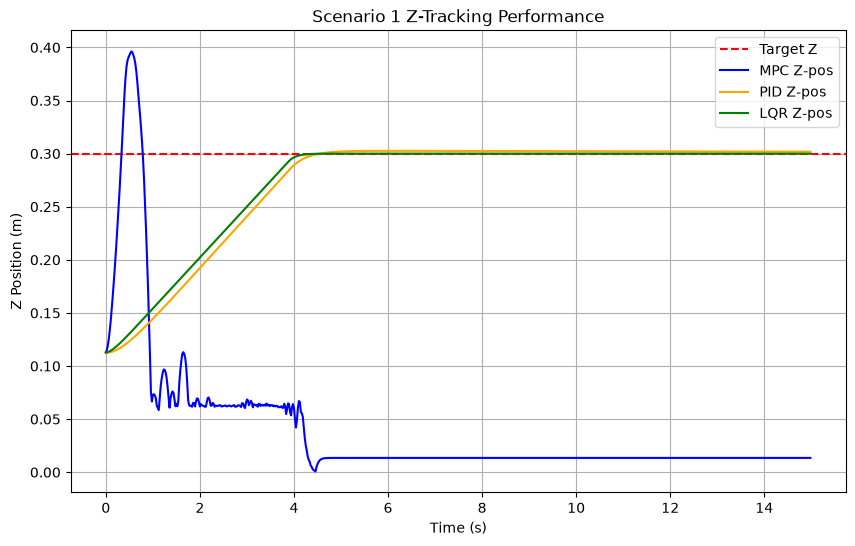

In [13]:
import matplotlib.pyplot as plt

scenario = "1"
mpc_z = np.load(f"results/scenario_{scenario}.npz")["states"][:, 2]
pid_z = np.load(f"results/pid_scenario_{scenario}.npz")["states"][:, 2]
lqr_z = np.load(f"results/lqr_scenario_{scenario}.npz")["states"][:, 2]

t = lambda arr: np.arange(len(arr)) / ctrl_freq

plt.figure(figsize=(10, 6))
plt.axhline(y=target_z, color="red", linestyle="--", label="Target Z")
plt.plot(t(mpc_z), mpc_z, color="blue", label="MPC Z-pos")
plt.plot(t(pid_z), pid_z, color="orange", label="PID Z-pos")
plt.plot(t(lqr_z), lqr_z, color="green", label="LQR Z-pos")
plt.xlabel("Time (s)")
plt.ylabel("Z Position (m)")
plt.title(f"Scenario {scenario} Z-Tracking Performance")
plt.legend()
plt.grid(True)
plt.savefig("results/plots/notebook_scenario_1_comparison.png", dpi=150)
plt.show()


## Notes / Known Findings

- **MPC controller instability:** across testing, the Koopman-MPC controller was
  found to become unstable (tipping past 90° roll/pitch) even during plain
  hovering with no disturbance and no climb requested — this is not specific to
  aggressive height targets or disturbance scenarios. Likely cause: Euler-angle
  and quaternion-based orientation representations are known to introduce
  singularities in Koopman lifting functions (see Narayanan et al., *SE(3)
  Koopman-MPC*, IFAC-PapersOnLine, 2023, which avoids this by lifting with
  rotation-matrix-based observables instead). This project deliberately stays
  faithful to the base paper's Euler-angle/quaternion representation and reports
  this as an evidenced limitation rather than working around it.
- **Fair-comparison check:** always confirm PID/LQR target heights match the MPC
  target before comparing — a mismatched target silently makes a baseline's task
  trivial and invalidates the comparison.
- **Novelty relative to base paper:** disturbance testing (payload + wind,
  scenarios 5–6) and a genuine classical-control baseline comparison (PID/LQR)
  are both extensions beyond the base paper, which only compares its own
  selector on vs. off (no PID/LQR baseline at all).
